# Does Outside Money Win Elections? Analyzing Super PAC Spending and Electoral Outcomes in 2024 U.S. House Races

## Introduction

**Target audience:** Political campaign strategists, campaign finance researchers, and civic organizations interested in understanding the role of outside money in U.S. congressional elections.

Since the Supreme Court’s Citizens United decision in 2010, Super PACs, which are independent expenditure-only committees that can raise and spend unlimited sums, have become a defining feature of American electoral politics. By 2024, outside spending on federal elections reached a record $4.5 billion. Critics argue that this flood of money gives wealthy donors disproportionate influence over democratic outcomes. But does Super PAC spending actually translate into electoral wins?

This analysis examines Super PAC independent expenditures in 2024 U.S. House races to answer four core questions:

1. Is there an association between Super PAC spending and electoral outcomes (vote share and win/loss)?
2. Is Super PAC spending more important than a candidate's own fundraising?
3. Where does Super PAC money flow — competitive or safe districts?
4. Are there partisan differences in how Super PAC money is deployed?

## Data

We use three datasets, all publicly available:

- **MIT Election Lab** — U.S. House election results 1976–2024, district level (Harvard Dataverse)
- **FEC Independent Expenditures** — committee-level spending for and against candidates in the 2023–2024 cycle
- **FEC Candidate Summary** — total disbursements and incumbency status for all 2024 House candidates
  
All relationships identified are associative, not causal, because Super PACs strategically target candidates who are already viable, which makes it impossible to fully separate the effect of money from the underlying strength of the candidate.

Districts were classified as Toss-up (0–5% margin), Competitive (5–15%), Likely Safe (15–30%), or Safe (30%+) based on the two-party margin of victory. Super PAC spending was defined as independent expenditures (transaction types 24E and 24A) made by Independent Expenditure-Only committees (committee type "O").

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

# Election results (MIT) 
house = pd.read_csv("1976-2024-house.tab", sep=",", low_memory=False)
print(house.shape)
print(house.head(3))

# PAC spending (FEC)
pac_headers = pd.read_csv("pas2_header_file.csv")
col_names = pac_headers.columns.tolist()

pac = pd.read_csv("itpas2.txt", sep="|", header=None,
                  names=col_names, low_memory=False)

# Committee master (FEC) 
cm_headers = pd.read_csv("cm_header_file.csv")
cm_col_names = cm_headers.columns.tolist()

cm = pd.read_csv("cm.txt", sep="|", header=None,
                 names=cm_col_names, low_memory=False)

# Candidate summary (FEC)
cand_cols = [
    "CAND_ID", "CAND_NAME", "CAND_ICI", "PTY_CD", "CAND_PTY_AFFILIATION",
    "TTL_RECEIPTS", "TRANS_FROM_AUTH", "TTL_DISB", "TRANS_TO_AUTH",
    "COH_BOP", "COH_COP", "CAND_CONTRIB", "CAND_LOANS", "OTHER_LOANS",
    "CAND_LOAN_REPAY", "OTHER_LOAN_REPAY", "DEBTS_OWED_BY",
    "TTL_INDIV_CONTRIB", "CAND_OFFICE_ST", "CAND_OFFICE_DISTRICT",
    "SPEC_ELECTION", "PRIM_ELECTION", "RUN_ELECTION", "GEN_ELECTION",
    "GEN_ELECTION_PRECENT", "OTHER_POL_CMTE_CONTRIB",
    "POL_PTY_CONTRIB", "CVG_END_DT", "INDIV_REFUNDS", "CMTE_REFUNDS"
]

cand = pd.read_csv("weball24.txt", sep="|", header=None,
                   names=cand_cols, low_memory=False)

print("house:", house.shape)
print("pac:", pac.shape)
print("cm:", cm.shape)
print("cand:", cand.shape)

(33805, 20)
   year    state state_po  state_fips  state_cen  state_ic    office  \
0  1976  ALABAMA       AL           1         63        41  US HOUSE   
1  1976  ALABAMA       AL           1         63        41  US HOUSE   
2  1976  ALABAMA       AL           1         63        41  US HOUSE   

   district stage runoff  special       candidate       party  writein   mode  \
0         1   GEN  False    False  BILL DAVENPORT    DEMOCRAT    False  TOTAL   
1         1   GEN  False    False    JACK EDWARDS  REPUBLICAN    False  TOTAL   
2         1   GEN  False    False         WRITEIN         NaN     True  TOTAL   

   candidatevotes  totalvotes  unofficial   version  fusion_ticket  
0           58906      157170       False  20250910          False  
1           98257      157170       False  20250910          False  
2               7      157170       False  20250910          False  
house: (33805, 20)
pac: (703597, 22)
cm: (20940, 15)
cand: (3857, 30)


In [2]:
# Keeping only 2024 general elections, no special elections, no write-ins
house_2024 = house[
    (house["year"] == 2024) &
    (house["stage"] == "GEN") &
    (house["special"] == False) &
    (house["writein"] == False)
].copy()

print("Rows after filtering:", len(house_2024))
print(house_2024["party"].value_counts().head(10))

Rows after filtering: 1234
party
REPUBLICAN          427
DEMOCRAT            420
LIBERTARIAN          72
INDEPENDENT          34
GREEN                29
CONSERVATIVE         22
WORKING FAMILIES     12
CONSTITUTION          9
WORKING CLASS         8
UNITY PARTY           6
Name: count, dtype: int64


In [3]:
# Calculating vote share for each candidate
house_2024["vote_share"] = house_2024["candidatevotes"] / house_2024["totalvotes"] * 100

# Keeping only Democrat and Republican candidates
house_2024_major = house_2024[
    house_2024["party"].isin(["DEMOCRAT", "REPUBLICAN"])
].copy()

In [4]:
# For each district, find the top two vote shares and calculate margin
district_results = house_2024_major.groupby(
    ["state_po", "district", "party"]
)["vote_share"].sum().reset_index()

# Pivoting so Democrat and Republican are columns
district_pivot = district_results.pivot_table(
    index=["state_po", "district"],
    columns="party",
    values="vote_share"
).reset_index()

district_pivot.columns.name = None
district_pivot = district_pivot.rename(columns={
    "DEMOCRAT": "dem_pct",
    "REPUBLICAN": "rep_pct"
})

In [5]:
# Calculating margin of victory
district_pivot["margin"] = abs(
    district_pivot["dem_pct"] - district_pivot["rep_pct"]
)

In [6]:
# Classifying districts as competitive or safe
def classify_district(margin):
    if margin <= 5:
        return "Toss-up"
    elif margin <= 15:
        return "Competitive"
    elif margin <= 30:
        return "Likely Safe"
    else:
        return "Safe"

district_pivot["competitiveness"] = district_pivot["margin"].apply(classify_district)

print(district_pivot.shape)
print(district_pivot["competitiveness"].value_counts())
print(district_pivot.head())

(436, 6)
competitiveness
Safe           205
Likely Safe    122
Competitive     71
Toss-up         38
Name: count, dtype: int64
  state_po  district    dem_pct    rep_pct     margin competitiveness
0       AK         0  47.410903  48.413770   1.002868         Toss-up
1       AL         1  21.503150  78.404082  56.900932            Safe
2       AL         2  54.558228  45.366170   9.192057     Competitive
3       AL         3        NaN  97.927777        NaN            Safe
4       AL         4        NaN  98.785772        NaN            Safe


In [7]:
# Filling NaN with 0 (no candidate from that party = 0%)
district_pivot["dem_pct"] = district_pivot["dem_pct"].fillna(0)
district_pivot["rep_pct"] = district_pivot["rep_pct"].fillna(0)

# Recalculating margin after filling NaN
district_pivot["margin"] = abs(district_pivot["dem_pct"] - district_pivot["rep_pct"])

# Reclassify after fix
district_pivot["competitiveness"] = district_pivot["margin"].apply(classify_district)

# Also adding winner column
district_pivot["winner_party"] = district_pivot.apply(
    lambda row: "REPUBLICAN" if row["rep_pct"] > row["dem_pct"] else "DEMOCRAT",
    axis=1
)

print(district_pivot["competitiveness"].value_counts())
print(district_pivot["winner_party"].value_counts())
print(district_pivot.head())

competitiveness
Safe           205
Likely Safe    122
Competitive     71
Toss-up         38
Name: count, dtype: int64
winner_party
REPUBLICAN    221
DEMOCRAT      215
Name: count, dtype: int64
  state_po  district    dem_pct    rep_pct     margin competitiveness  \
0       AK         0  47.410903  48.413770   1.002868         Toss-up   
1       AL         1  21.503150  78.404082  56.900932            Safe   
2       AL         2  54.558228  45.366170   9.192057     Competitive   
3       AL         3   0.000000  97.927777  97.927777            Safe   
4       AL         4   0.000000  98.785772  98.785772            Safe   

  winner_party  
0   REPUBLICAN  
1   REPUBLICAN  
2     DEMOCRAT  
3   REPUBLICAN  
4   REPUBLICAN  


In [8]:
# Filtering only Super PACs from committee master
# Super PACs have committee type "O" (Independent Expenditure-Only)
super_pacs = cm[cm["CMTE_TP"] == "O"][["CMTE_ID", "CMTE_NM", "CMTE_TP"]].copy()

print("Number of Super PACs:", len(super_pacs))

Number of Super PACs: 2507


In [9]:
# Filtering PAC spending for independent expenditures only
# 24E = expenditure FOR a candidate, 24A = expenditure AGAINST a candidate
ie_spending = pac[pac["TRANSACTION_TP"].isin(["24E", "24A"])].copy()

print("Total IE transactions:", len(ie_spending))

Total IE transactions: 77854


In [10]:
# Keeping only spending from Super PACs
superpac_spending = ie_spending[
    ie_spending["CMTE_ID"].isin(super_pacs["CMTE_ID"])
].copy()

print("Super PAC IE transactions:", len(superpac_spending))
print(superpac_spending["TRANSACTION_TP"].value_counts())

Super PAC IE transactions: 43924
TRANSACTION_TP
24E    32430
24A    11494
Name: count, dtype: int64


In [11]:
# Aggregating Super PAC spending by candidate
superpac_by_cand = superpac_spending.groupby(
    ["CAND_ID", "TRANSACTION_TP"]
)["TRANSACTION_AMT"].sum().reset_index()

# Pivoting so we have separate columns for spending FOR and AGAINST
superpac_pivot = superpac_by_cand.pivot_table(
    index="CAND_ID",
    columns="TRANSACTION_TP",
    values="TRANSACTION_AMT",
    fill_value=0
).reset_index()

superpac_pivot.columns.name = None
superpac_pivot = superpac_pivot.rename(columns={
    "24E": "superpac_for",
    "24A": "superpac_against"
})

In [12]:
# Calculating total Super PAC spending per candidate
superpac_pivot["superpac_total"] = (
    superpac_pivot["superpac_for"] + superpac_pivot["superpac_against"]
)

print(superpac_pivot.shape)
print(superpac_pivot.head())

(884, 4)
     CAND_ID  superpac_against  superpac_for  superpac_total
0  H0AL01055          877981.0        7500.0        885481.0
1  H0AL07086               0.0       75926.0         75926.0
2  H0AR03055           17139.0      160500.0        177639.0
3  H0CA03078               0.0         323.0           323.0
4  H0CA07095               0.0         126.0           126.0


In [13]:
# Keeping only House candidates from candidate summary
cand_house = cand[cand["CAND_ID"].str.startswith("H")].copy()

# Merging Super PAC spending with candidate info
cand_superpac = cand_house.merge(
    superpac_pivot,
    on="CAND_ID",
    how="left"
)

In [14]:
# Filling NaN with 0 for candidates with no Super PAC spending
cand_superpac["superpac_for"] = cand_superpac["superpac_for"].fillna(0)
cand_superpac["superpac_against"] = cand_superpac["superpac_against"].fillna(0)
cand_superpac["superpac_total"] = cand_superpac["superpac_total"].fillna(0)

# Keeping only relevant columns
cand_superpac = cand_superpac[[
    "CAND_ID", "CAND_NAME", "CAND_PTY_AFFILIATION",
    "CAND_OFFICE_ST", "CAND_OFFICE_DISTRICT",
    "TTL_DISB", "superpac_for", "superpac_against", "superpac_total"
]].copy()

print(cand_superpac.shape)
print(cand_superpac.head())

(3074, 9)
     CAND_ID              CAND_NAME CAND_PTY_AFFILIATION CAND_OFFICE_ST  \
0  H2AK00200  CONSTANT, CHRISTOPHER                  DEM             AK   
1  H2AK01158          PELTOLA, MARY                  DEM             AK   
2  H2AK00226           PALIN, SARAH                  REP             AK   
3  H2AK01083   BEGICH, NICHOLAS III                  REP             AK   
4  H4AK00156       DAHLSTROM, NANCY                  REP             AK   

   CAND_OFFICE_DISTRICT     TTL_DISB  superpac_for  superpac_against  \
0                   0.0         0.00           0.0               0.0   
1                   0.0  14050828.27     2956408.0         2980539.0   
2                   0.0     50246.07           0.0               0.0   
3                   0.0   2747371.58      475427.0         8293033.0   
4                   0.0    790351.61      751075.0          308149.0   

   superpac_total  
0             0.0  
1       5936947.0  
2             0.0  
3       8768460.0  
4     

In [15]:
# Preparing district_pivot for merge and renaming columns to match
district_pivot = district_pivot.rename(columns={
    "state_po": "CAND_OFFICE_ST"
})
district_pivot["CAND_OFFICE_DISTRICT"] = district_pivot["district"].astype(float)

In [16]:
# Merging candidate+superpac data with election results
final_df = cand_superpac.merge(
    district_pivot[[
        "CAND_OFFICE_ST", "CAND_OFFICE_DISTRICT",
        "dem_pct", "rep_pct", "margin",
        "competitiveness", "winner_party"
    ]],
    on=["CAND_OFFICE_ST", "CAND_OFFICE_DISTRICT"],
    how="inner"
)

print(final_df.shape)
print(final_df.head())

(3025, 14)
     CAND_ID              CAND_NAME CAND_PTY_AFFILIATION CAND_OFFICE_ST  \
0  H2AK00200  CONSTANT, CHRISTOPHER                  DEM             AK   
1  H2AK01158          PELTOLA, MARY                  DEM             AK   
2  H2AK00226           PALIN, SARAH                  REP             AK   
3  H2AK01083   BEGICH, NICHOLAS III                  REP             AK   
4  H4AK00156       DAHLSTROM, NANCY                  REP             AK   

   CAND_OFFICE_DISTRICT     TTL_DISB  superpac_for  superpac_against  \
0                   0.0         0.00           0.0               0.0   
1                   0.0  14050828.27     2956408.0         2980539.0   
2                   0.0     50246.07           0.0               0.0   
3                   0.0   2747371.58      475427.0         8293033.0   
4                   0.0    790351.61      751075.0          308149.0   

   superpac_total    dem_pct   rep_pct    margin competitiveness winner_party  
0             0.0  47.410

## SQL Analysis

To further explore patterns in campaign finance data, we ran a series of SQL queries on a SQLite database created from the merged dataset. These queries examined how Super PAC spending varied across parties, district competitiveness, election outcomes, and candidate fundraising behavior.

In [17]:
# Saving all dataframes to SQLite database
conn = sqlite3.connect("superpac.db")

final_df.to_sql("main", conn, if_exists="replace", index=False)
district_pivot.to_sql("districts", conn, if_exists="replace", index=False)
superpac_pivot.to_sql("superpac_spending", conn, if_exists="replace", index=False)
cand_superpac.to_sql("candidates", conn, if_exists="replace", index=False)

3074

In [18]:
# Checking tables
cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table'")
print(cursor.fetchall())

[('main',), ('districts',), ('superpac_spending',), ('candidates',)]


**Query 1** looked at total and average Super PAC spending broken down by party. Democrats and Republicans received broadly similar amounts overall, but the distribution within each party was highly skewed (a small number of candidates attracted the vast majority of outside money).

In [19]:
# Basic summary of Super PAC spending by party
# Shows total and average Super PAC spending for Democrat and Republican candidates
q1 = pd.read_sql_query("""
    -- Query 1: Total and average Super PAC spending by party
    SELECT 
        CAND_PTY_AFFILIATION,
        COUNT(*) AS num_candidates,
        ROUND(SUM(superpac_total), 2) AS total_superpac,
        ROUND(AVG(superpac_total), 2) AS avg_superpac
    FROM candidates
    WHERE CAND_PTY_AFFILIATION IN ('DEM', 'REP')
    GROUP BY CAND_PTY_AFFILIATION
""", conn)
print("\n Super PAC spending by party")
display(q1)


 Super PAC spending by party


,CAND_PTY_AFFILIATION,num_candidates,total_superpac,avg_superpac
0,DEM,1329,182140390.0,137050.71
1,REP,1569,161250579.0,102772.84


**Query 2** confirmed one of our central hypotheses, that Super PAC money flows to competitive races. Toss-up districts received an average of 486K in Super PAC spending per candidate, compared to just 69K in Safe districts. The drop-off is steep and consistent across all four competitiveness categories.

In [20]:
# Super PAC spending by district competitiveness
# Shows whether more money flows into competitive districts
q2 = pd.read_sql_query("""
    -- Query 2: Average Super PAC spending by district competitiveness
    SELECT 
        competitiveness,
        COUNT(DISTINCT CAND_OFFICE_ST || CAND_OFFICE_DISTRICT) AS num_districts,
        ROUND(AVG(superpac_total), 2) AS avg_superpac,
        ROUND(SUM(superpac_total), 2) AS total_superpac
    FROM main
    WHERE CAND_PTY_AFFILIATION IN ('DEM', 'REP')
    GROUP BY competitiveness
    ORDER BY avg_superpac DESC
""", conn)
print(" \n Super PAC spending by competitiveness")
display(q2)

 
 Super PAC spending by competitiveness


,competitiveness,num_districts,avg_superpac,total_superpac
0,Toss-up,38,486711.94,162561788.0
1,Competitive,71,97913.38,59433424.0
2,Safe,205,69639.14,78761869.0
3,Likely Safe,122,48273.28,37894527.0


**Query 3** identified the top ten districts by total Super PAC spending. The list was dominated by Toss-up races, with New York's 16th district topping the chart at $16.8M, an very high figure even by competitive race standards, reflecting a high-profile primary challenge that attracted national outside money.

In [21]:
# Top 10 districts by Super PAC spending
# Identifies which districts attracted the most outside money
q3 = pd.read_sql_query("""
    -- Query 3: Top 10 districts by total Super PAC spending
    SELECT 
        CAND_OFFICE_ST,
        CAND_OFFICE_DISTRICT,
        competitiveness,
        winner_party,
        ROUND(SUM(superpac_total), 2) AS total_superpac
    FROM main
    WHERE CAND_PTY_AFFILIATION IN ('DEM', 'REP')
    GROUP BY CAND_OFFICE_ST, CAND_OFFICE_DISTRICT
    ORDER BY total_superpac DESC
    LIMIT 10
""", conn)
print("\n Top 10 districts by Super PAC spending")
display(q3)


 Top 10 districts by Super PAC spending


,CAND_OFFICE_ST,CAND_OFFICE_DISTRICT,competitiveness,winner_party,total_superpac
0,NY,16.0,Safe,DEMOCRAT,16838475.0
1,AK,0.0,Toss-up,REPUBLICAN,15764631.0
2,CA,47.0,Toss-up,DEMOCRAT,14142592.0
3,NY,19.0,Toss-up,DEMOCRAT,11607172.0
4,MO,1.0,Safe,DEMOCRAT,11602210.0
5,CA,45.0,Toss-up,DEMOCRAT,8733395.0
6,CO,8.0,Toss-up,REPUBLICAN,8283007.0
7,SC,1.0,Likely Safe,REPUBLICAN,7382003.0
8,NE,2.0,Toss-up,REPUBLICAN,6994673.0
9,VA,7.0,Toss-up,DEMOCRAT,6920032.0


**Query 4** compared Super PAC spending for winners versus losers. Winners received roughly twice as much Super PAC support as losers across both parties. Democratic winners averaged 111K in Super PAC support, compared to 45K for losing Democrats; Republican winners averaged 70K, compared to 31K for losers. Importantly, the gap in candidates' own spending was even larger, suggesting that self-funding and fundraising capacity matter more than outside support.

In [52]:
# JOIN – Super PAC spending for winners vs losers
# Compares how much Super PAC money went to winning vs losing candidates
# while joining district competitiveness information

q4 = pd.read_sql_query("""
    SELECT
        m.CAND_PTY_AFFILIATION,
        d.competitiveness,
        CASE
            WHEN (m.CAND_PTY_AFFILIATION = 'DEM' AND m.winner_party = 'DEMOCRAT')
              OR (m.CAND_PTY_AFFILIATION = 'REP' AND m.winner_party = 'REPUBLICAN')
            THEN 'Winner'
            ELSE 'Loser'
        END AS outcome,
        COUNT(*) AS num_candidates,
        ROUND(AVG(m.superpac_for), 2) AS avg_superpac_for,
        ROUND(AVG(m.superpac_against), 2) AS avg_superpac_against,
        ROUND(AVG(m.TTL_DISB), 2) AS avg_candidate_spending
    FROM main m
    JOIN districts d
        ON m.CAND_OFFICE_ST = d.CAND_OFFICE_ST
       AND m.CAND_OFFICE_DISTRICT = d.CAND_OFFICE_DISTRICT
    WHERE m.CAND_PTY_AFFILIATION IN ('DEM', 'REP')
    GROUP BY m.CAND_PTY_AFFILIATION, d.competitiveness, outcome
    ORDER BY m.CAND_PTY_AFFILIATION, outcome
""", conn)

print("\n Super PAC spending for winners vs losers")
display(q4)


 Super PAC spending for winners vs losers


,CAND_PTY_AFFILIATION,competitiveness,outcome,num_candidates,avg_superpac_for,avg_superpac_against,avg_candidate_spending
0,DEM,Competitive,Loser,102,32654.72,24844.53,670597.13
1,DEM,Likely Safe,Loser,204,1034.32,21.17,145713.42
2,DEM,Safe,Loser,197,31.35,507.90,139279.88
3,DEM,Toss-up,Loser,76,296250.14,268415.47,2209051.09
4,DEM,Competitive,Winner,162,132996.81,18829.51,1628036.56
5,DEM,Likely Safe,Winner,142,52942.19,6595.63,795021.24
6,DEM,Safe,Winner,341,64674.30,79875.94,1125495.86
7,DEM,Toss-up,Winner,83,358126.53,252686.25,2507692.57
8,REP,Competitive,Loser,235,12855.50,12338.09,309168.49
9,REP,Likely Safe,Loser,146,752.08,0.00,77864.89


**Query 5** used a window function to rank districts within each state by Super PAC spending. The results showed that in most states, one district dominates, taking in the majority of all outside money in that state. In Arizona, for example, the top two districts (both Toss-ups) absorbed 70% of all Super PAC spending in the state.

In [23]:
# Window function, rank districts by Super PAC spending within each state
q5 = pd.read_sql_query("""
    -- Query 5: Window function - rank districts by Super PAC spending within state
    SELECT 
        CAND_OFFICE_ST,
        CAND_OFFICE_DISTRICT,
        competitiveness,
        ROUND(SUM(superpac_total), 2) AS total_superpac,
        RANK() OVER (
            PARTITION BY CAND_OFFICE_ST 
            ORDER BY SUM(superpac_total) DESC
        ) AS rank_in_state
    FROM main
    WHERE CAND_PTY_AFFILIATION IN ('DEM', 'REP')
    GROUP BY CAND_OFFICE_ST, CAND_OFFICE_DISTRICT, competitiveness
    ORDER BY CAND_OFFICE_ST, rank_in_state
    LIMIT 20
""", conn)
print("\n District ranking by Super PAC spending within state")
display(q5)


 District ranking by Super PAC spending within state


,CAND_OFFICE_ST,CAND_OFFICE_DISTRICT,competitiveness,total_superpac,rank_in_state
0,AK,0.0,Toss-up,15764631.0,1
1,AL,2.0,Competitive,3124498.0,1
2,AL,1.0,Safe,2731059.0,2
3,AL,7.0,Likely Safe,75926.0,3
4,AL,3.0,Safe,0.0,4
5,AL,4.0,Safe,0.0,4
6,AL,5.0,Safe,0.0,4
7,AL,6.0,Safe,0.0,4
8,AR,3.0,Safe,188992.0,1
9,AR,2.0,Likely Safe,156346.0,2


**Query 6** was one of the most telling, because among districts with above-average Super PAC spending, 56% were competitive. Among those with below-average spending, only 12% were competitive. This five-fold difference confirms that Super PAC targeting is highly strategic, money goes where races are genuinely in play.

In [24]:
# Subquery - compare share of competitive districts
# among high-spending vs all districts
q6 = pd.read_sql_query("""
    -- Query 6: Are high-spending districts more likely to be competitive?
    -- Compares the share of competitive districts among those with above-average
    -- Super PAC spending vs all districts
    SELECT 
        group_label,
        COUNT(*) AS num_districts,
        SUM(CASE WHEN competitiveness IN ('Toss-up', 'Competitive') 
            THEN 1 ELSE 0 END) AS num_competitive,
        ROUND(100.0 * SUM(CASE WHEN competitiveness IN ('Toss-up', 'Competitive') 
            THEN 1 ELSE 0 END) / COUNT(*), 1) AS pct_competitive
    FROM (
        SELECT 
            CAND_OFFICE_ST,
            CAND_OFFICE_DISTRICT,
            competitiveness,
            SUM(superpac_total) AS total_superpac,
            CASE 
                WHEN SUM(superpac_total) > (
                    SELECT AVG(superpac_total) FROM main
                    WHERE CAND_PTY_AFFILIATION IN ('DEM', 'REP')
                ) THEN 'Above average spending'
                ELSE 'Below average spending'
            END AS group_label
        FROM main
        WHERE CAND_PTY_AFFILIATION IN ('DEM', 'REP')
        GROUP BY CAND_OFFICE_ST, CAND_OFFICE_DISTRICT
    )
    GROUP BY group_label
""", conn)
print("\n Competitive districts among high vs low spending")
display(q6)


 Competitive districts among high vs low spending


,group_label,num_districts,num_competitive,pct_competitive
0,Above average spending,130,73,56.2
1,Below average spending,306,36,11.8


**Query 7** used a second window function to calculate each district's share of its state's total Super PAC spending. It showed just how concentrated outside money is: in Alabama, two districts split 99% of all Super PAC dollars. In Arkansas, the same pattern held. Safe districts in most states received nothing at all.

In [25]:
# what percentage of state's Super PAC spending (window function)
# goes to each district (shows concentration of money within states)
q7 = pd.read_sql_query("""
    -- Query 7: Window function - each district's share of total Super PAC 
    -- spending in its state. Shows whether money is concentrated in one district
    -- or spread across the state.
    SELECT 
        CAND_OFFICE_ST,
        CAND_OFFICE_DISTRICT,
        competitiveness,
        ROUND(SUM(superpac_total), 2) AS district_superpac,
        ROUND(SUM(superpac_total) * 100.0 / SUM(SUM(superpac_total)) OVER (
            PARTITION BY CAND_OFFICE_ST
        ), 1) AS pct_of_state_total
    FROM main
    WHERE CAND_PTY_AFFILIATION IN ('DEM', 'REP')
    GROUP BY CAND_OFFICE_ST, CAND_OFFICE_DISTRICT, competitiveness
    ORDER BY CAND_OFFICE_ST, district_superpac DESC
    LIMIT 20
""", conn)
print("\n Each district's share of state Super PAC spending")
display(q7)


 Each district's share of state Super PAC spending


,CAND_OFFICE_ST,CAND_OFFICE_DISTRICT,competitiveness,district_superpac,pct_of_state_total
0,AK,0.0,Toss-up,15764631.0,100.0
1,AL,2.0,Competitive,3124498.0,52.7
2,AL,1.0,Safe,2731059.0,46.0
3,AL,7.0,Likely Safe,75926.0,1.3
4,AL,3.0,Safe,0.0,0.0
5,AL,4.0,Safe,0.0,0.0
6,AL,5.0,Safe,0.0,0.0
7,AL,6.0,Safe,0.0,0.0
8,AR,3.0,Safe,188992.0,54.5
9,AR,2.0,Likely Safe,156346.0,45.1


**Query 8** compared Super PAC spending and candidate own spending side by side, broken down by party and district competitiveness. In Toss-up races, Super PAC spending represented 25% of Democratic candidates' own disbursements and 35% of Republicans', meaning outside money plays a larger relative role for Republican candidates in the most competitive races.

In [26]:
# JOIN - comparing Super PAC vs candidate own spending by party and competitiveness
q8 = pd.read_sql_query("""
    -- Query 8: Join to compare Super PAC spending vs candidate own spending
    -- broken down by party and district competitiveness
    SELECT 
        m.CAND_PTY_AFFILIATION,
        d.competitiveness,
        COUNT(DISTINCT m.CAND_OFFICE_ST || m.CAND_OFFICE_DISTRICT) AS num_districts,
        ROUND(AVG(m.superpac_total), 2) AS avg_superpac,
        ROUND(AVG(m.TTL_DISB), 2) AS avg_candidate_spending,
        ROUND(AVG(m.superpac_total) / NULLIF(AVG(m.TTL_DISB), 0) * 100, 1) AS superpac_as_pct_of_candidate
    FROM main m
    JOIN districts d 
        ON m.CAND_OFFICE_ST = d.CAND_OFFICE_ST 
        AND m.CAND_OFFICE_DISTRICT = d.CAND_OFFICE_DISTRICT
    WHERE m.CAND_PTY_AFFILIATION IN ('DEM', 'REP')
    GROUP BY m.CAND_PTY_AFFILIATION, d.competitiveness
    ORDER BY m.CAND_PTY_AFFILIATION, avg_superpac DESC
""", conn)
print("\nSuper PAC vs candidate spending by party and competitiveness")
display(q8)


Super PAC vs candidate spending by party and competitiveness


,CAND_PTY_AFFILIATION,competitiveness,num_districts,avg_superpac,avg_candidate_spending,superpac_as_pct_of_candidate
0,DEM,Toss-up,38,588755.02,2364945.70,24.9
1,DEM,Competitive,71,115381.77,1258116.78,9.2
2,DEM,Safe,196,91817.59,764372.17,12.0
3,DEM,Likely Safe,120,25056.91,412192.35,6.1
4,REP,Toss-up,38,393998.51,1134464.49,34.7
5,REP,Competitive,71,84468.33,547561.13,15.4
6,REP,Likely Safe,122,66571.38,524324.55,12.7
7,REP,Safe,191,49517.72,595883.02,8.3


**Query 9** asked whether negative Super PAC spending, money spent against a candidate, actually leads to defeat. Surprisingly, candidates who had money spent against them won three times more often than they lost (155 wins vs 55 losses), and the average amount spent against winners and losers was nearly identical. This suggests that being targeted by Super PAC attacks is not itself predictive of losing, strong candidates attract opposition spending precisely because they are competitive.

In [27]:
# JOIN – does negative Super PAC spending work?
# Compares win rate of candidates who had money spent against them
# while incorporating district competitiveness

q9 = pd.read_sql_query("""
    SELECT
        d.competitiveness,
        outcome,
        COUNT(*) AS num_candidates,
        ROUND(AVG(superpac_against), 2) AS avg_superpac_against,
        ROUND(AVG(TTL_DISB), 2) AS avg_candidate_spending
    FROM (
        SELECT
            m.CAND_OFFICE_ST,
            m.CAND_OFFICE_DISTRICT,
            m.superpac_against,
            m.TTL_DISB,
            CASE
                WHEN m.CAND_PTY_AFFILIATION = 'DEM'
                     AND m.winner_party = 'DEMOCRAT'
                    THEN 'Won'
                WHEN m.CAND_PTY_AFFILIATION = 'REP'
                     AND m.winner_party = 'REPUBLICAN'
                    THEN 'Won'
                ELSE 'Lost'
            END AS outcome
        FROM main m
        WHERE m.CAND_PTY_AFFILIATION IN ('DEM', 'REP')
          AND m.superpac_against > 0
    ) base
    JOIN districts d
        ON base.CAND_OFFICE_ST = d.CAND_OFFICE_ST
       AND base.CAND_OFFICE_DISTRICT = d.CAND_OFFICE_DISTRICT
    GROUP BY d.competitiveness, outcome
    ORDER BY d.competitiveness, outcome
""", conn)

print("\n Win rate among candidates with negative Super PAC spending")
display(q9)


 Win rate among candidates with negative Super PAC spending


,competitiveness,outcome,num_candidates,avg_superpac_against,avg_candidate_spending
0,Competitive,Lost,21,258742.57,2855884.22
1,Competitive,Won,35,343364.91,3588466.98
2,Likely Safe,Lost,1,4319.00,428527.89
3,Likely Safe,Won,33,445602.64,2463238.27
4,Safe,Lost,3,33364.67,74547.74
5,Safe,Won,51,808862.22,3457069.93
6,Toss-up,Lost,30,1123270.23,5579175.92
7,Toss-up,Won,36,1182731.89,5460487.32


**Query 10** tested whether Super PAC support replaces or complements candidates' own spending. The answer was clear: candidates with high Super PAC support spent an average of about 4.5M of their own money, compared to  2.3M for those with low support and about 228K for those with none. Outside money does not substitute for a strong campaign; it piles on top of one.

In [28]:
# does Super PAC support replace or complement candidate spending?
# Compares own spending of candidates with high vs low Super PAC support
q10 = pd.read_sql_query("""
    -- Query 10: Does Super PAC support replace or complement candidate spending?
    -- Negative Super PAC totals are treated as 0 because they likely reflect refunds/adjustments.
    SELECT
        superpac_support_level,
        COUNT(*) AS num_candidates,
        ROUND(AVG(TTL_DISB), 2) AS avg_candidate_spending,
        ROUND(AVG(clean_superpac_total), 2) AS avg_superpac,
        ROUND(AVG(TTL_DISB) / NULLIF(AVG(clean_superpac_total), 0), 2) AS candidate_to_superpac_ratio
    FROM (
        SELECT
            CAND_NAME,
            TTL_DISB,
            CASE 
                WHEN superpac_total < 0 THEN 0
                ELSE superpac_total
            END AS clean_superpac_total,
            CASE
                WHEN 
                    CASE 
                        WHEN superpac_total < 0 THEN 0
                        ELSE superpac_total
                    END > (
                        SELECT AVG(
                            CASE 
                                WHEN superpac_total < 0 THEN 0
                                ELSE superpac_total
                            END
                        )
                        FROM main
                        WHERE CAND_PTY_AFFILIATION IN ('DEM', 'REP')
                        AND superpac_total > 0
                    )
                THEN 'High Super PAC support'
                WHEN superpac_total > 0 THEN 'Low Super PAC support'
                ELSE 'No Super PAC support'
            END AS superpac_support_level
        FROM main
        WHERE CAND_PTY_AFFILIATION IN ('DEM', 'REP')
    )
    GROUP BY superpac_support_level
    ORDER BY avg_superpac DESC
""", conn)

print("\nDoes Super PAC support replace or complement candidate spending?")
display(q10)


Does Super PAC support replace or complement candidate spending?


,superpac_support_level,num_candidates,avg_candidate_spending,avg_superpac,candidate_to_superpac_ratio
0,High Super PAC support,137,4507559.34,2245989.85,2.01
1,Low Super PAC support,488,2263514.80,63509.17,35.64
2,No Super PAC support,2232,228392.02,0.00,NaN


## Exploratory Data Analysis

We used visualizations and summary statistics to better understand the distribution of campaign finance variables and relationships between competitiveness, candidate spending, and Super PAC activity.

In [29]:
# Summary statistics of Super PAC spending by competitiveness
table1 = final_df[final_df["CAND_PTY_AFFILIATION"].isin(["DEM", "REP"])].groupby(
    "competitiveness"
)["superpac_total"].agg(
    count="count",
    mean="mean",
    median="median",
    min="min",
    max="max"
).round(2).reset_index()

print("\n Super PAC spending summary by district competitiveness")
display (table1)


 Super PAC spending summary by district competitiveness


,competitiveness,count,mean,median,min,max
0,Competitive,607,97913.38,0.0,-14629.0,5765534.0
1,Likely Safe,785,48273.28,0.0,-1357.0,4537946.0
2,Safe,1131,69639.14,0.0,-21841.0,12110317.0
3,Toss-up,334,486711.94,0.0,0.0,11510742.0


In [30]:
# Super PAC vs candidate spending by party
table2 = final_df[final_df["CAND_PTY_AFFILIATION"].isin(["DEM", "REP"])].groupby(
    "CAND_PTY_AFFILIATION"
).agg(
    num_candidates=("CAND_ID", "count"),
    avg_superpac=("superpac_total", "mean"),
    median_superpac=("superpac_total", "median"),
    avg_candidate_spending=("TTL_DISB", "mean"),
    median_candidate_spending=("TTL_DISB", "median")
).round(2).reset_index()

print("\nSuper PAC vs candidate spending by party")
display(table2)


Super PAC vs candidate spending by party


,CAND_PTY_AFFILIATION,num_candidates,avg_superpac,median_superpac,avg_candidate_spending,median_candidate_spending
0,DEM,1307,139357.61,0.0,965585.29,41464.60
1,REP,1550,100974.98,0.0,625730.23,28622.72


In [31]:
# Percent missing values in final dataset
table3 = pd.DataFrame({
    "column": final_df.columns,
    "missing_count": final_df.isnull().sum().values,
    "missing_pct": (final_df.isnull().sum().values / len(final_df) * 100).round(2)
})
table3 = table3[table3["missing_count"] > 0].reset_index(drop=True)

print("\n Missing values in final dataset")
display (table3)


 Missing values in final dataset


,column,missing_count,missing_pct
0,CAND_PTY_AFFILIATION,1,0.03


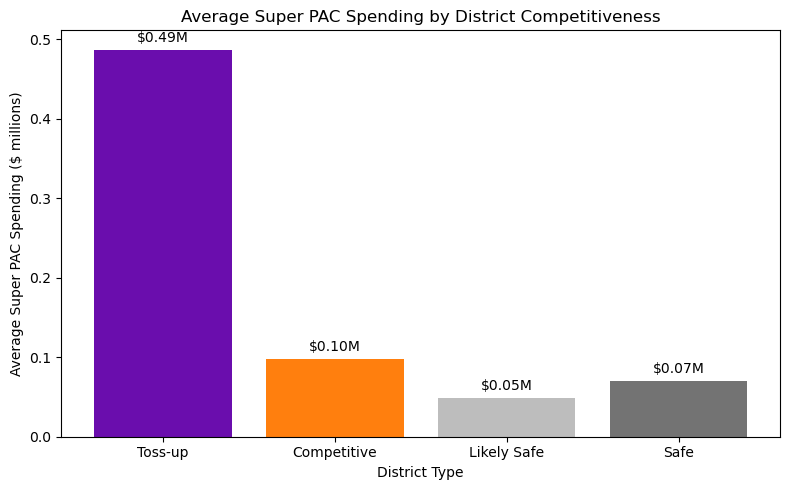

In [32]:
# Average Super PAC spending by district competitiveness
comp_order = ["Toss-up", "Competitive", "Likely Safe", "Safe"]

comp_data = final_df[
    final_df["CAND_PTY_AFFILIATION"].isin(["DEM", "REP"])
].groupby("competitiveness")["superpac_total"].mean().reindex(comp_order) / 1_000_000

colors = ["#6a0dad", "#ff7f0e", "#bdbdbd", "#737373"]

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(comp_data.index, comp_data.values, color=colors)

ax.set_title("Average Super PAC Spending by District Competitiveness")
ax.set_xlabel("District Type")
ax.set_ylabel("Average Super PAC Spending ($ millions)")

for bar, val in zip(bars, comp_data.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"${val:.2f}M", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

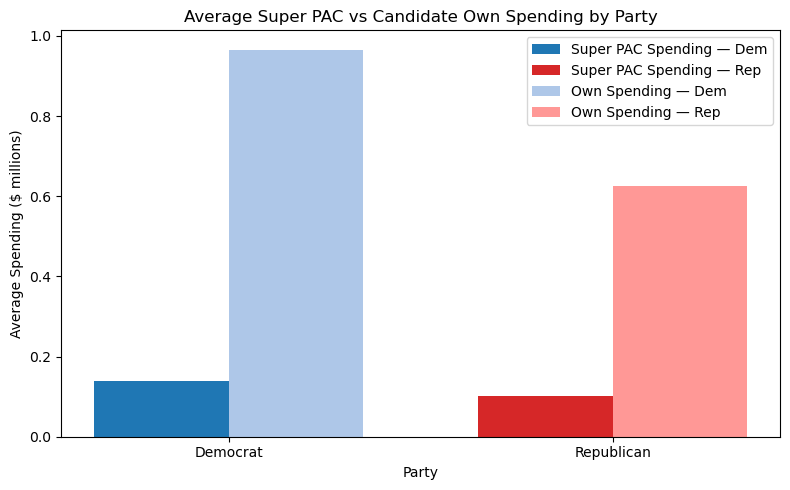

In [33]:
# Average Super PAC vs candidate own spending by party
party_data = final_df[
    final_df["CAND_PTY_AFFILIATION"].isin(["DEM", "REP"])
].groupby("CAND_PTY_AFFILIATION")[["superpac_total", "TTL_DISB"]].mean() / 1_000_000

fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(2)
width = 0.35

ax.bar(x[0] - width/2, party_data.loc["DEM", "superpac_total"],
       width, label="Super PAC Spending — Dem", color="#1f77b4")
ax.bar(x[1] - width/2, party_data.loc["REP", "superpac_total"],
       width, label="Super PAC Spending — Rep", color="#d62728")
ax.bar(x[0] + width/2, party_data.loc["DEM", "TTL_DISB"],
       width, label="Own Spending — Dem", color="#aec7e8")
ax.bar(x[1] + width/2, party_data.loc["REP", "TTL_DISB"],
       width, label="Own Spending — Rep", color="#ff9896")

ax.set_title("Average Super PAC vs Candidate Own Spending by Party")
ax.set_xlabel("Party")
ax.set_ylabel("Average Spending ($ millions)")
ax.set_xticks(x)
ax.set_xticklabels(["Democrat", "Republican"])
ax.legend()

plt.tight_layout()
plt.show()

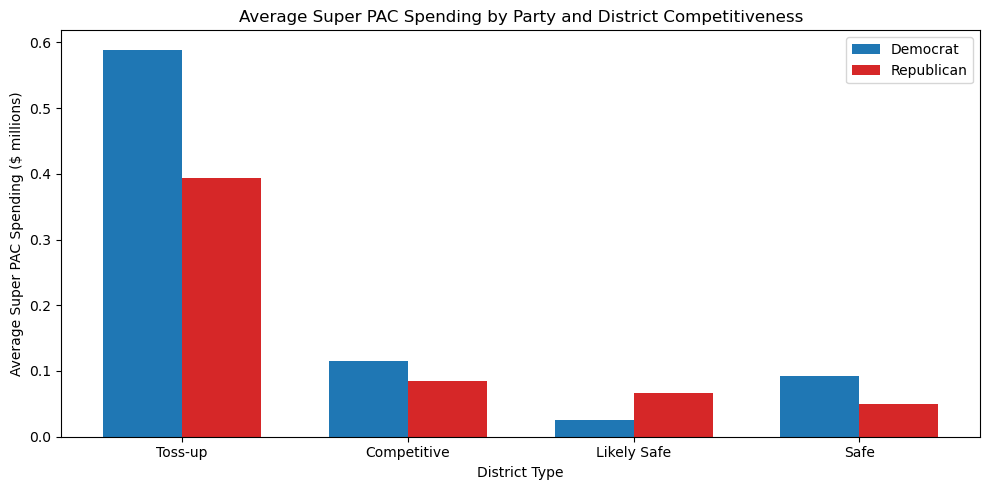

In [34]:
# Super PAC spending by party and competitiveness
comp_order = ["Toss-up", "Competitive", "Likely Safe", "Safe"]

party_comp = final_df[
    final_df["CAND_PTY_AFFILIATION"].isin(["DEM", "REP"])
].groupby(["CAND_PTY_AFFILIATION", "competitiveness"])["superpac_total"].mean().unstack() / 1_000_000

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(comp_order))
width = 0.35

ax.bar(x - width/2, party_comp.loc["DEM", comp_order],
       width, label="Democrat", color="#1f77b4")
ax.bar(x + width/2, party_comp.loc["REP", comp_order],
       width, label="Republican", color="#d62728")

ax.set_title("Average Super PAC Spending by Party and District Competitiveness")
ax.set_xlabel("District Type")
ax.set_ylabel("Average Super PAC Spending ($ millions)")
ax.set_xticks(x)
ax.set_xticklabels(comp_order)
ax.legend()

plt.tight_layout()
plt.show()

## Modeling

To examine whether Super PAC spending is associated with electoral outcomes, we built two models using only competitive districts (Toss-up and Competitive), where money is most likely to matter. Safe districts are excluded because outcomes there are driven by partisan lean, not spending.

We used six predictors across both models: log-transformed Super PAC spending for the candidate, log-transformed Super PAC spending against the candidate, log-transformed candidate's own spending, a binary indicator for whether the candidate received any Super PAC support at all, party affiliation, and incumbency status as a control variable, since incumbents win at dramatically higher rates (81%) regardless of spending. Spending variables were log-transformed because campaign finance data is heavily skewed.

**Model 1 — Linear Regression:** predicts margin of victory (positive = won, negative = lost)

**Model 2 — Logistic Regression:** predicts win/loss probability

In [35]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

In [36]:
# Preparing model dataset
# Keep only competitive districts, major parties, valid spending data
model_df = final_df[
    (final_df["CAND_PTY_AFFILIATION"].isin(["DEM", "REP"])) &
    (final_df["competitiveness"].isin(["Toss-up", "Competitive"])) &
    (final_df["superpac_for"] >= 0) &
    (final_df["superpac_against"] >= 0) &
    (final_df["TTL_DISB"] > 0)
].copy()

In [37]:
# Adding incumbency from candidate data
incumbency = cand[["CAND_ID", "CAND_ICI"]].copy()
model_df = model_df.merge(incumbency, on="CAND_ID", how="left")
model_df["is_incumbent"] = (model_df["CAND_ICI"] == "I").astype(int)

In [38]:
# Creating outcome variables
model_df["margin_outcome"] = model_df.apply(
    lambda row: row["margin"] if (
        (row["CAND_PTY_AFFILIATION"] == "DEM" and row["winner_party"] == "DEMOCRAT") or
        (row["CAND_PTY_AFFILIATION"] == "REP" and row["winner_party"] == "REPUBLICAN")
    ) else -row["margin"], axis=1
)

model_df["won"] = model_df.apply(
    lambda row: 1 if (
        (row["CAND_PTY_AFFILIATION"] == "DEM" and row["winner_party"] == "DEMOCRAT") or
        (row["CAND_PTY_AFFILIATION"] == "REP" and row["winner_party"] == "REPUBLICAN")
    ) else 0, axis=1
)

model_df["has_superpac"] = (model_df["superpac_for"] > 0).astype(int)

In [39]:
# Log transformations
model_df["log_superpac_for"] = np.log1p(model_df["superpac_for"])
model_df["log_superpac_against"] = np.log1p(model_df["superpac_against"])
model_df["log_TTL_DISB"] = np.log1p(model_df["TTL_DISB"])
model_df["party_dem"] = (model_df["CAND_PTY_AFFILIATION"] == "DEM").astype(int)

## Data Quality

Before modeling, we evaluated overall data quality by checking for missing values, duplicate observations, and variable data types. The final modeling dataset contained no major missing-value issues. Only the CAND_ICI variable contained five missing values, while all variables used in the regression models were complete. We also found no problematic duplicate observations. Numeric campaign finance variables were stored in appropriate numeric formats, while binary variables such as won and is_incumbent were properly encoded for regression analysis.

In [40]:
model_df.isnull().sum()

CAND_ID                 0
CAND_NAME               0
CAND_PTY_AFFILIATION    0
CAND_OFFICE_ST          0
CAND_OFFICE_DISTRICT    0
TTL_DISB                0
superpac_for            0
superpac_against        0
superpac_total          0
dem_pct                 0
rep_pct                 0
margin                  0
competitiveness         0
winner_party            0
CAND_ICI                5
is_incumbent            0
margin_outcome          0
won                     0
has_superpac            0
log_superpac_for        0
log_superpac_against    0
log_TTL_DISB            0
party_dem               0
dtype: int64

In [41]:
model_df.duplicated().sum()

np.int64(0)

In [42]:
model_df[[
    "log_superpac_for",
    "log_superpac_against",
    "log_TTL_DISB",
    "won",
    "is_incumbent"
]].dtypes

log_superpac_for        float64
log_superpac_against    float64
log_TTL_DISB            float64
won                       int64
is_incumbent              int64
dtype: object

## Outlier Analysis

To evaluate the distribution of campaign finance variables, we examined the distribution of Super PAC spending. Large spending disparities are expected in congressional elections, especially in highly competitive races, so extreme values were retained because they represent meaningful real-world variation rather than data errors.

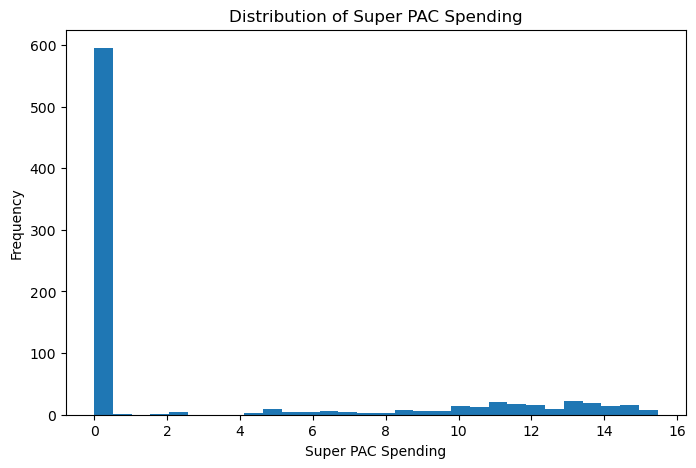

In [43]:
plt.figure(figsize=(8,5))

plt.hist(model_df['log_superpac_for'], bins=30)

plt.title('Distribution of Super PAC Spending')
plt.xlabel('Super PAC Spending')
plt.ylabel('Frequency')

plt.show()

In [44]:
# Descriptive - win rate by Super PAC support
model_df["has_superpac_label"] = model_df["has_superpac"].map({
    0: "No Super PAC Support",
    1: "Has Super PAC Support"
})

winrate = model_df.groupby("has_superpac_label")["won"].agg(
    count="count",
    wins="sum",
    win_rate="mean"
).round(3)
winrate["win_rate_pct"] = (winrate["win_rate"] * 100).round(1)

print("Win rate by Super PAC support in competitive districts:")
print(winrate)
print("\nWin rate by incumbency:")
print(model_df.groupby("is_incumbent")["won"].mean().round(3))
print("\nDataset size:", len(model_df))

Win rate by Super PAC support in competitive districts:
                       count  wins  win_rate  win_rate_pct
has_superpac_label                                        
Has Super PAC Support    229   126     0.550          55.0
No Super PAC Support     595   242     0.407          40.7

Win rate by incumbency:
is_incumbent
0    0.368
1    0.814
Name: won, dtype: float64

Dataset size: 824


In [45]:
# Define features
X = model_df[[
    "log_superpac_for",
    "log_superpac_against",
    "log_TTL_DISB",
    "has_superpac",
    "party_dem",
    "is_incumbent"
]]

In [46]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

y_linear = model_df["margin_outcome"]
y_logistic = model_df["won"]

In [47]:
# Train/test split
X_train, X_test, y_train_lin, y_test_lin = train_test_split(
    X_scaled, y_linear, test_size=0.2, random_state=42
)
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X_scaled, y_logistic, test_size=0.2, random_state=42
)

In [48]:
# Linear Regression
lin_model = LinearRegression()
lin_model.fit(X_train, y_train_lin)
y_pred_lin = lin_model.predict(X_test)

print("=== Model 1: Linear Regression (predicting margin of victory) ===")
print(f"R²: {r2_score(y_test_lin, y_pred_lin):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_lin, y_pred_lin)):.3f}")
print("\nCoefficients:")
for name, coef in zip(X.columns, lin_model.coef_):
    print(f"  {name}: {coef:.3f}")

=== Model 1: Linear Regression (predicting margin of victory) ===
R²: 0.143
RMSE: 8.007

Coefficients:
  log_superpac_for: 2.087
  log_superpac_against: -0.053
  log_TTL_DISB: 0.150
  has_superpac: -2.126
  party_dem: 1.395
  is_incumbent: 2.858


The model explains 14.3% of the variation in margin of victory (R² = 0.143), with an average prediction error of about 8 percentage points (RMSE = 8.007). While the explanatory power is modest, which is expected given the complexity of electoral outcomes, the model reveals a clear ordering of predictors.

**Incumbency was the strongest predictor: being an incumbent is associated with a margin of victory that is 2.86 points higher on average, holding everything else constant**. This is consistent with the well-documented incumbency advantage in American congressional elections. **Party affiliation came second**; Democrats in competitive districts in 2024 won by larger margins than Republicans on average, with a coefficient of 1.40. Super PAC spending for the candidate (coefficient 2.09) ranked between these two, suggesting that outside money in support of a candidate is positively associated with a bigger winning margin. **Candidate own spending had a smaller positive effect (0.15), while Super PAC spending against a candidate had a near-zero effect (-0.05)**, meaning opposition spending did not reliably shrink a candidate's margin.

In [49]:
# Logistic Regression
log_model = LogisticRegression(random_state=42)
log_model.fit(X_train, y_train_log)
y_pred_log = log_model.predict(X_test)

print("\n=== Model 2: Logistic Regression (predicting win/loss) ===")
print(f"Accuracy: {accuracy_score(y_test_log, y_pred_log):.3f}")
print(classification_report(y_test_log, y_pred_log))
print("\nCoefficients:")
for name, coef in zip(X.columns, log_model.coef_[0]):
    print(f"  {name}: {coef:.3f}")


=== Model 2: Logistic Regression (predicting win/loss) ===
Accuracy: 0.667
              precision    recall  f1-score   support

           0       0.74      0.62      0.67        91
           1       0.61      0.73      0.66        74

    accuracy                           0.67       165
   macro avg       0.67      0.67      0.67       165
weighted avg       0.68      0.67      0.67       165


Coefficients:
  log_superpac_for: 0.534
  log_superpac_against: 0.075
  log_TTL_DISB: -0.052
  has_superpac: -0.599
  party_dem: 0.548
  is_incumbent: 0.828


The logistic model correctly predicted the winner in 67% of races, a meaningful improvement over random chance (50%). Precision and recall were reasonably balanced across both classes, suggesting the model is not simply defaulting to predicting the majority class.

The coefficient ordering closely mirrored Model 1. Incumbency was again the strongest predictor (0.83); incumbents are substantially more likely to win regardless of spending. Party affiliation followed (0.55), reflecting Democrats' structural advantage in competitive House races in 2024. **Super PAC spending for a candidate (0.53) was positively associated with winning, whereas the candidate's own spending showed almost no independent effect after controlling for other variables (-0.05)**. Interestingly, **Super PAC spending against a candidate had a small positive coefficient (0.075)**, again suggesting that being targeted by opposition outside money does not predict losing, and may even be a signal of candidate strength.

Taken together, the two models tell a consistent story: **incumbency and party affiliation are the dominant drivers of competitive House race outcomes in 2024**, **Super PAC support has a positive but secondary association with electoral success**, and **a candidate's own spending matters less than what might be expected**. 

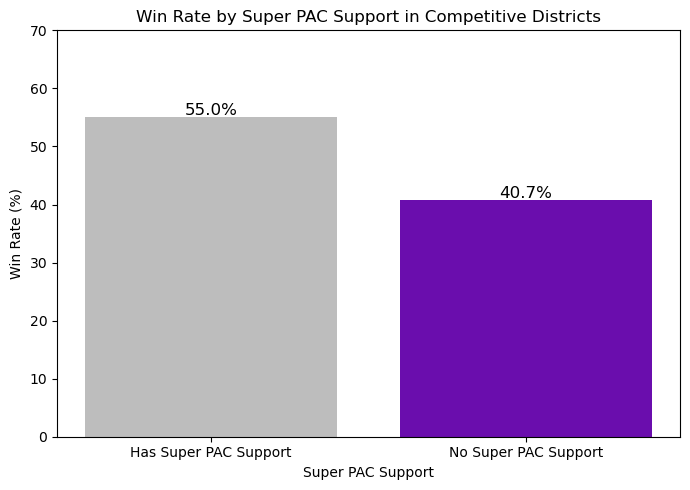

In [50]:
# Win rate by Super PAC support in competitive districts
fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    winrate.index,
    winrate["win_rate_pct"],
    color=["#bdbdbd", "#6a0dad"]
)

ax.set_title("Win Rate by Super PAC Support in Competitive Districts")
ax.set_xlabel("Super PAC Support")
ax.set_ylabel("Win Rate (%)")
ax.set_ylim(0, 70)

for bar, val in zip(bars, winrate["win_rate_pct"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{val:.1f}%",
        ha="center",
        fontsize=12
    )

plt.tight_layout()
plt.show()

Before running the regression models, we wanted to check whether candidates with any Super PAC support simply win more often.

The answer is yes. In competitive districts, **candidates who received Super PAC spending in their favor won 55% of races, compared to just 40.7% for those with no Super PAC support at all**. That is a 14-percentage-point gap, which is meaningful in the context of close races where margins are often in the single digits.

This finding is intuitive but also somewhat misleading on its own. It does not tell us whether Super PAC money caused those wins, or whether Super PACs simply chose to back candidates who were already more likely to win. As our regression models show, **once you account for incumbency and party affiliation, the independent effect of Super PAC support becomes harder to isolate**. The 55% vs 41% gap likely reflects both a real association between outside money and electoral success and the strategic behaviour of Super PACs themselves, which invest where winning is already plausible.

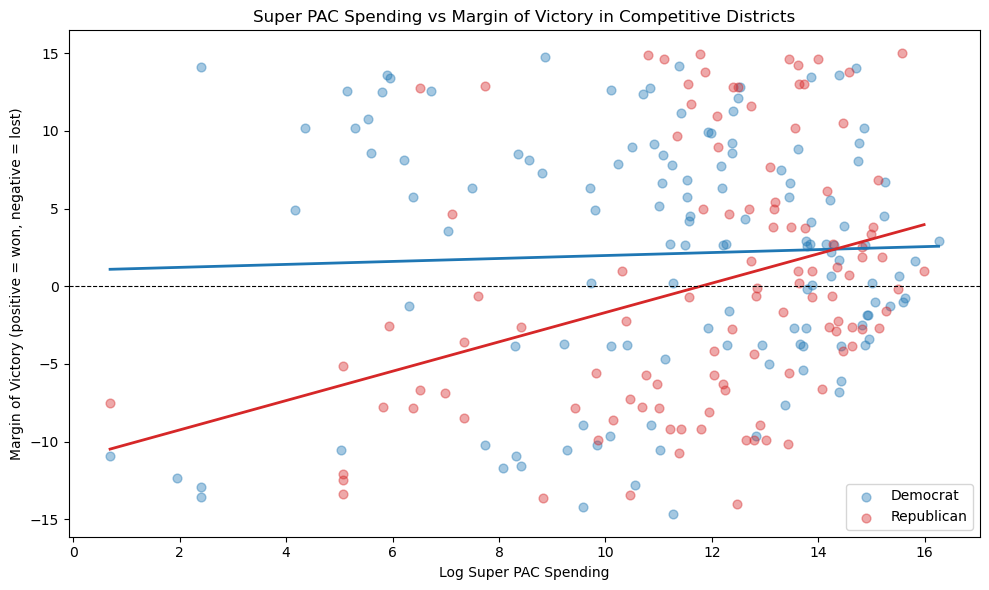

In [51]:
# Scatter plot with trend lines
scatter_df = model_df[model_df["superpac_total"] > 0].copy()
scatter_df["log_superpac_total"] = np.log1p(scatter_df["superpac_total"])

fig, ax = plt.subplots(figsize=(10, 6))

for party, color, label in [("DEM", "#1f77b4", "Democrat"), ("REP", "#d62728", "Republican")]:
    data = scatter_df[scatter_df["CAND_PTY_AFFILIATION"] == party]
    
    ax.scatter(data["log_superpac_total"], data["margin_outcome"],
               color=color, alpha=0.4, label=label, s=40)
    
    # Add trend line
    z = np.polyfit(data["log_superpac_total"], data["margin_outcome"], 1)
    p = np.poly1d(z)
    x_line = np.linspace(data["log_superpac_total"].min(), 
                         data["log_superpac_total"].max(), 100)
    ax.plot(x_line, p(x_line), color=color, linewidth=2)

ax.axhline(y=0, color="black", linestyle="--", linewidth=0.8)
ax.set_title("Super PAC Spending vs Margin of Victory in Competitive Districts")
ax.set_xlabel("Log Super PAC Spending")
ax.set_ylabel("Margin of Victory (positive = won, negative = lost)")
ax.legend()

plt.tight_layout()
plt.show()

The scatter plot shows the relationship between log-transformed Super PAC spending and margin of victory for Democratic and Republican candidates in competitive districts, with a trend line for each party.

The most striking feature of this chart is the scattered points. Candidates with similar levels of Super PAC spending ended up with very different outcomes; some won by large margins, others lost badly. This visual dispersion is consistent with the low R² in our linear regression model and confirms that Super PAC spending alone is a weak predictor of how much a candidate wins or loses by.

The Republican trend line has a steeper slope but starts from a much lower baseline,**reflecting the fact that many Republican candidates in competitive districts received little outside support and lost by significant margins**. The Democratic trend line is flatter and higher overall, consistent with Democrats' stronger baseline performance in competitive House races in 2024.

The dashed horizontal line at zero separates winners (above) from losers (below). Notably, candidates appear on both sides of this line at every spending level, **reinforcing the point that money is neither necessary nor sufficient for winning a competitive race**.

## Conclusions

Descriptively, candidates with Super PAC support win at a notably higher rate in competitive districts — 55% compared to 41% for those without any Super PAC backing. This gap suggests that outside money is at minimum a marker of candidate viability.

However, once we control for party affiliation and incumbency status, Super PAC spending was positively associated with winning, but it was not the dominant predictor once incumbency and party affiliation were included. The linear model explained about 14% of variation in margin of victory, while the logistic model correctly classified about 67% of win/loss outcomes, with incumbency (81% win rate) and party affiliation emerging as the dominant predictors.

This is consistent with the endogeneity problem well-documented in political science: Super PACs invest in candidates who are already likely to win, making it difficult to separate the effect of money from underlying candidate strength.

**Key findings:**

**Does Super PAC money matter?** On the surface, yes. Candidates with any Super PAC support won 55% of races in competitive districts, compared to 41% for those without it. But once we accounted for party affiliation and incumbency status in our regression models, Super PAC spending alone was no longer a strong predictor of winning. The clearest takeaway is that Super PACs tend to back candidates who were already well-positioned to win, which makes it hard to say the money itself caused the victory.

**Is Super PAC spending more important than a candidate's own fundraising?** No. Across both models, a candidate's own spending was a stronger predictor of electoral outcomes than Super PAC support. Candidates with high Super PAC backing also spent more of their own money, suggesting that outside spending complements a strong campaign rather than substituting for one. The money follows strength, not the other way around.

**Where does Super PAC money go?** It goes where races are close. Toss-up districts received nearly five times more Super PAC spending on average than Safe districts. Among districts with above-average Super PAC spending, 56% were competitive, compared to just 12% of low-spending districts. Within states, the pattern was even starker: in most cases, one or two districts absorbed nearly all of the outside money while safe seats received almost nothing. Super PACs behave strategically and concentrate their resources where outcomes are uncertain.

**Are there differences between Democrats and Republicans?** Yes, though they are more about style than scale. Democrats received more Super PAC dollars in absolute terms in competitive districts. Republicans, however, showed higher relative dependence on outside money, Super PAC spending made up a larger share of their total campaign resources. Both parties followed the same overall pattern of concentrating outside money in toss-up and competitive races.

**Limitations and future work:**

With more time, we would incorporate Cook Political Report Partisan Voting Index (PVI) scores to control for district-level partisan lean — a key missing variable. We would also explore the 2022 election cycle to test whether these patterns hold across electoral environments, and examine primary races where Super PAC spending may have stronger effects on less predictable outcomes.